In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
semilla_aleatoria = 42
np.random.seed(semilla_aleatoria)

numero_observaciones = 200
desviacion_ruido = 0.5

limite_inferior_x = 0.1
limite_superior_x = 1.0

In [3]:
def funcion(valor_x):
    return 2 + 4 * (5*valor_x - 1) * (4*valor_x - 2) * (valor_x - 0.8)**2

In [4]:
variable_independiente_x = np.random.uniform(
    low=limite_inferior_x,
    high=limite_superior_x,
    size=numero_observaciones
)

ruido_gaussiano = np.random.normal(
    loc=0.0,
    scale=desviacion_ruido,
    size=numero_observaciones
)

variable_dependiente_y_sin_ruido = funcion(variable_independiente_x)
variable_dependiente_y_observada = variable_dependiente_y_sin_ruido + ruido_gaussiano


In [5]:
indices_ordenados = np.argsort(variable_independiente_x)

x_ordenada = variable_independiente_x[indices_ordenados]
y_observada_ordenada = variable_dependiente_y_observada[indices_ordenados]
y_sin_ruido_ordenada = variable_dependiente_y_sin_ruido[indices_ordenados]


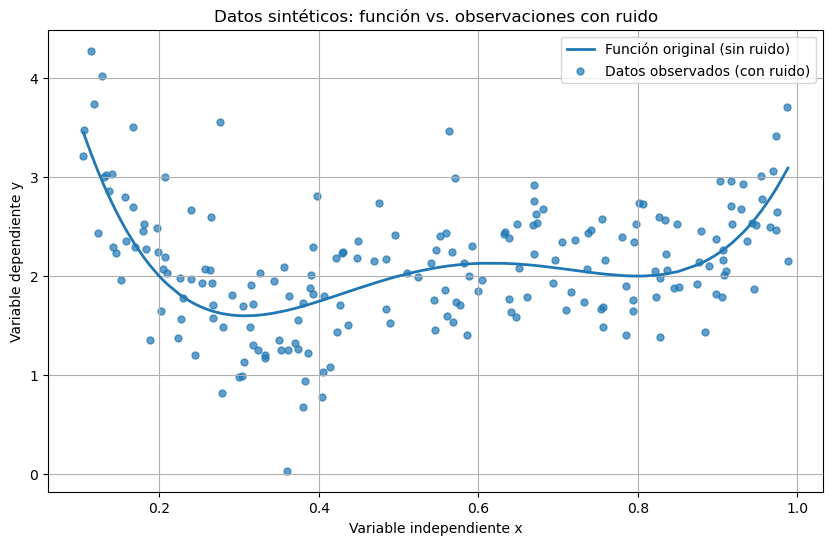

In [6]:
plt.figure(figsize=(10, 6))

# Función (línea)
plt.plot(x_ordenada, y_sin_ruido_ordenada, linewidth=2, label="Función original (sin ruido)")

# Datos con ruido (puntos)
plt.scatter(x_ordenada, y_observada_ordenada, s=25, alpha=0.7, label="Datos observados (con ruido)")

plt.title("Datos sintéticos: función vs. observaciones con ruido")
plt.xlabel("Variable independiente x")
plt.ylabel("Variable dependiente y")
plt.grid(True)
plt.legend()
plt.show()


In [7]:
print("Primeros 10 valores de x:", np.round(variable_independiente_x[:10], 4))
print("Primeros 10 valores de y (observada):", np.round(variable_dependiente_y_observada[:10], 4))
print("Semilla:", semilla_aleatoria)
print("Número de observaciones:", numero_observaciones)
print("Desviación del ruido (σ):", desviacion_ruido)


Primeros 10 valores de x: [0.4371 0.9556 0.7588 0.6388 0.2404 0.2404 0.1523 0.8796 0.641  0.7373]
Primeros 10 valores de y (observada): [1.5028 2.7834 2.1662 1.7694 2.6701 1.9742 1.9613 2.4589 1.6384 2.4337]
Semilla: 42
Número de observaciones: 200
Desviación del ruido (σ): 0.5


In [8]:
total_observaciones = len(variable_independiente_x)
print("Total de observaciones:", total_observaciones)


Total de observaciones: 200


In [9]:
proporcion_entrenamiento = 0.6
proporcion_validacion = 0.2
proporcion_prueba = 0.2

cantidad_entrenamiento = int(total_observaciones * proporcion_entrenamiento)
cantidad_validacion = int(total_observaciones * proporcion_validacion)
cantidad_prueba = total_observaciones - cantidad_entrenamiento - cantidad_validacion

In [10]:
print("Datos de entrenamiento:", cantidad_entrenamiento)
print("Datos de validación:", cantidad_validacion)
print("Datos de prueba:", cantidad_prueba)

Datos de entrenamiento: 120
Datos de validación: 40
Datos de prueba: 40


In [11]:
indices_aleatorios = np.random.permutation(total_observaciones)

In [12]:
indices_entrenamiento = indices_aleatorios[:cantidad_entrenamiento]

indices_validacion = indices_aleatorios[
    cantidad_entrenamiento : cantidad_entrenamiento + cantidad_validacion
]

indices_prueba = indices_aleatorios[
    cantidad_entrenamiento + cantidad_validacion :
]

In [13]:
x_entrenamiento = variable_independiente_x[indices_entrenamiento]
y_entrenamiento = variable_dependiente_y_observada[indices_entrenamiento]

In [14]:
x_validacion = variable_independiente_x[indices_validacion]
y_validacion = variable_dependiente_y_observada[indices_validacion]

In [15]:
x_prueba = variable_independiente_x[indices_prueba]
y_prueba = variable_dependiente_y_observada[indices_prueba]

In [16]:
print("Entrenamiento:", len(x_entrenamiento), "observaciones")
print("Validación:", len(x_validacion), "observaciones")
print("Prueba:", len(x_prueba), "observaciones")

print("Suma total:", 
      len(x_entrenamiento) + len(x_validacion) + len(x_prueba))

Entrenamiento: 120 observaciones
Validación: 40 observaciones
Prueba: 40 observaciones
Suma total: 200


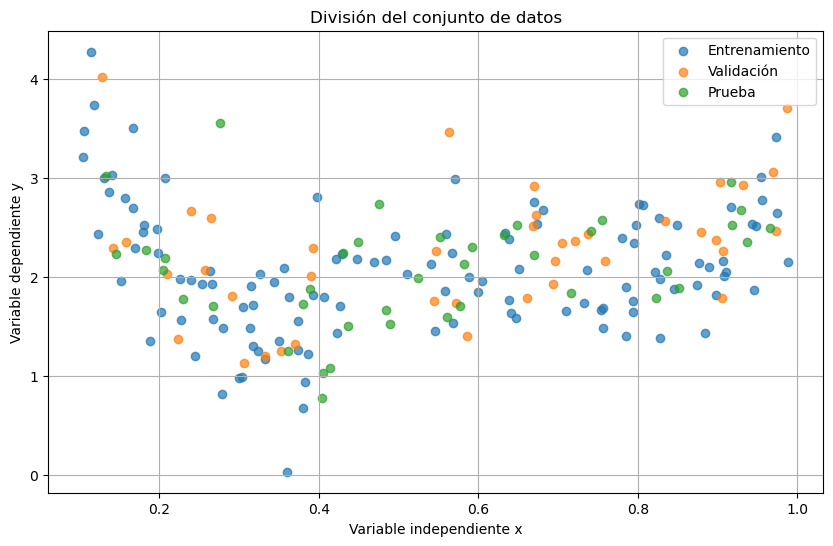

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(x_entrenamiento, y_entrenamiento, label="Entrenamiento", alpha=0.7)
plt.scatter(x_validacion, y_validacion, label="Validación", alpha=0.7)
plt.scatter(x_prueba, y_prueba, label="Prueba", alpha=0.7)

plt.title("División del conjunto de datos")
plt.xlabel("Variable independiente x")
plt.ylabel("Variable dependiente y")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def error_cuadratico_medio(valores_reales, valores_predichos):
    diferencia = valores_reales - valores_predichos
    error = diferencia ** 2
    return np.mean(error)

In [19]:
grados_polinomiales = [1, 3, 5, 9, 15]

In [20]:
x_grafica = np.linspace(limite_inferior_x, limite_superior_x, 300)


Modelo polinomial de grado: 1
Error entrenamiento: 0.4194
Error validación: 0.4567
Error prueba: 0.3092


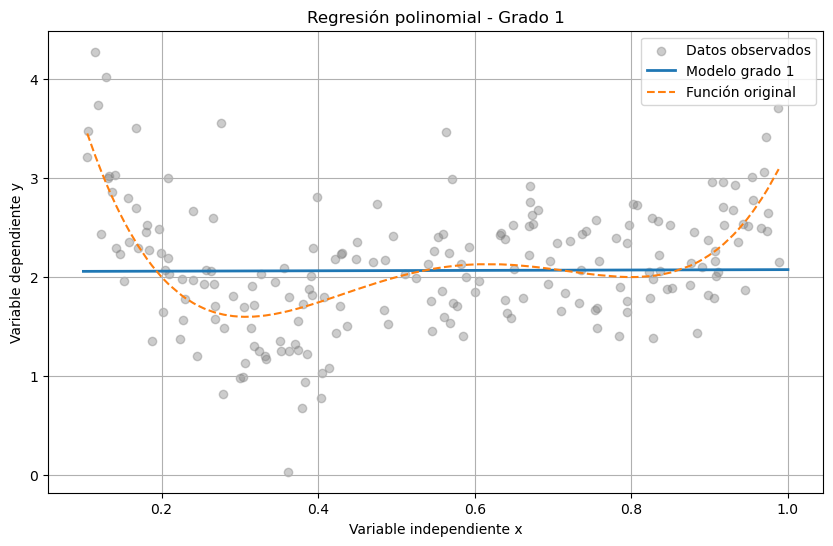


Modelo polinomial de grado: 3
Error entrenamiento: 0.2726
Error validación: 0.3521
Error prueba: 0.2557


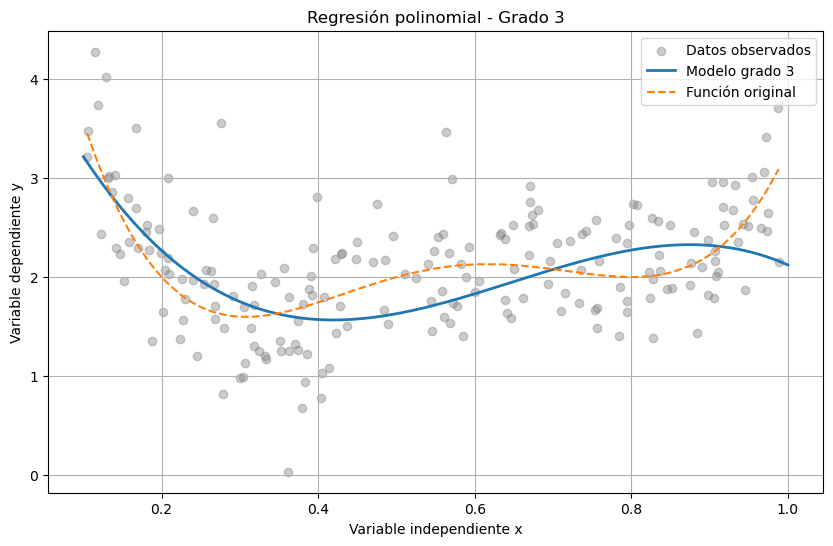


Modelo polinomial de grado: 5
Error entrenamiento: 0.2127
Error validación: 0.2784
Error prueba: 0.2418


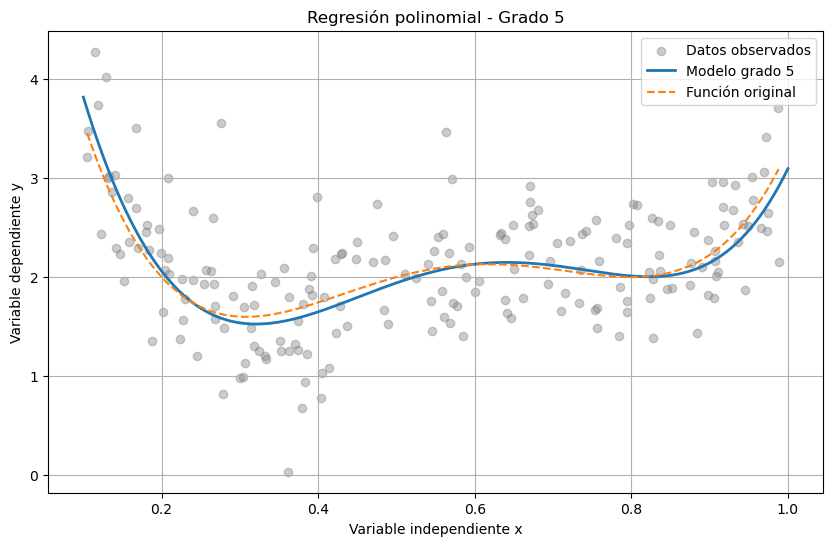


Modelo polinomial de grado: 9
Error entrenamiento: 0.203
Error validación: 0.2987
Error prueba: 0.2544


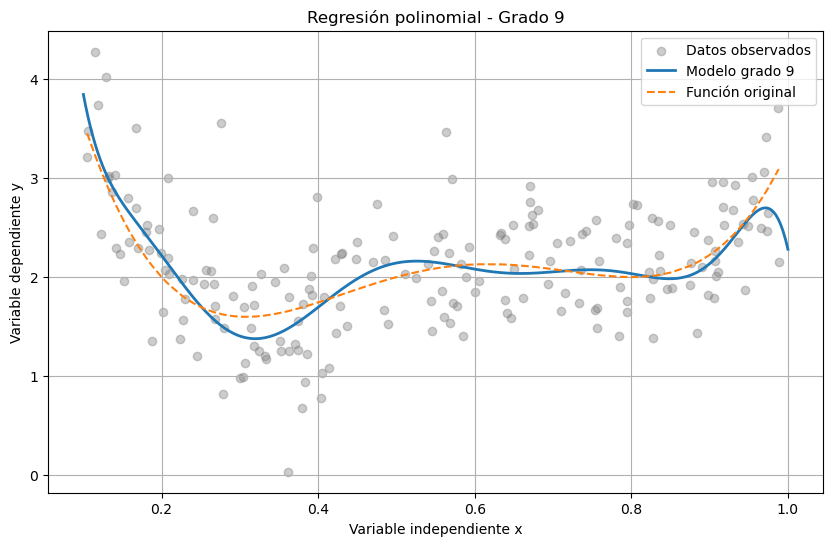


Modelo polinomial de grado: 15
Error entrenamiento: 0.1901
Error validación: 0.3208
Error prueba: 0.2827


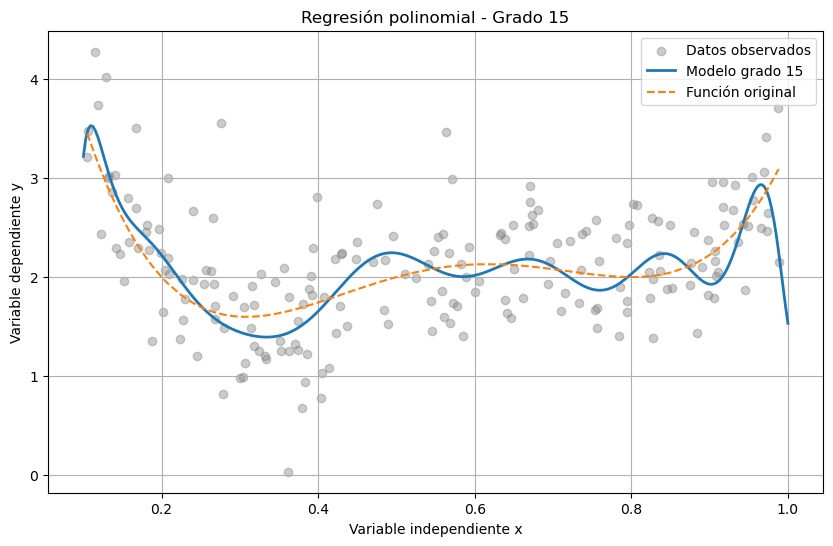

In [21]:
for grado_actual in grados_polinomiales:
    
    print("\n==============================")
    print("Modelo polinomial de grado:", grado_actual)
    print("==============================")
    
    coeficientes_modelo = np.polyfit(x_entrenamiento, y_entrenamiento, grado_actual)
    modelo_polinomial = np.poly1d(coeficientes_modelo)
    
    y_entrenamiento_predicha = modelo_polinomial(x_entrenamiento)
    y_validacion_predicha = modelo_polinomial(x_validacion)
    y_prueba_predicha = modelo_polinomial(x_prueba)
    
    error_entrenamiento = error_cuadratico_medio(y_entrenamiento, y_entrenamiento_predicha)
    error_validacion = error_cuadratico_medio(y_validacion, y_validacion_predicha)
    error_prueba = error_cuadratico_medio(y_prueba, y_prueba_predicha)
    
    print("Error entrenamiento:", round(error_entrenamiento, 4))
    print("Error validación:", round(error_validacion, 4))
    print("Error prueba:", round(error_prueba, 4))
    
    # 6) Graficar resultados
    plt.figure(figsize=(10, 6))
    
    plt.scatter(variable_independiente_x, variable_dependiente_y_observada,
                color="gray", alpha=0.4, label="Datos observados")
    
    plt.plot(x_grafica, modelo_polinomial(x_grafica),
             linewidth=2, label="Modelo grado " + str(grado_actual))
    
    plt.plot(x_ordenada, y_sin_ruido_ordenada,
             linestyle="dashed", label="Función original")
    
    plt.title("Regresión polinomial - Grado " + str(grado_actual))
    plt.xlabel("Variable independiente x")
    plt.ylabel("Variable dependiente y")
    plt.legend()
    plt.grid(True)
    plt.show()


In [22]:
errores_entrenamiento = []
errores_validacion = []
errores_prueba = []


In [23]:
for grado_actual in grados_polinomiales:
    
    coeficientes_modelo = np.polyfit(x_entrenamiento, y_entrenamiento, grado_actual)
    modelo_polinomial = np.poly1d(coeficientes_modelo)
    
    y_entrenamiento_predicha = modelo_polinomial(x_entrenamiento)
    y_validacion_predicha = modelo_polinomial(x_validacion)
    y_prueba_predicha = modelo_polinomial(x_prueba)
    
    error_ent = error_cuadratico_medio(y_entrenamiento, y_entrenamiento_predicha)
    error_val = error_cuadratico_medio(y_validacion, y_validacion_predicha)
    error_pru = error_cuadratico_medio(y_prueba, y_prueba_predicha)
    
    errores_entrenamiento.append(error_ent)
    errores_validacion.append(error_val)
    errores_prueba.append(error_pru)


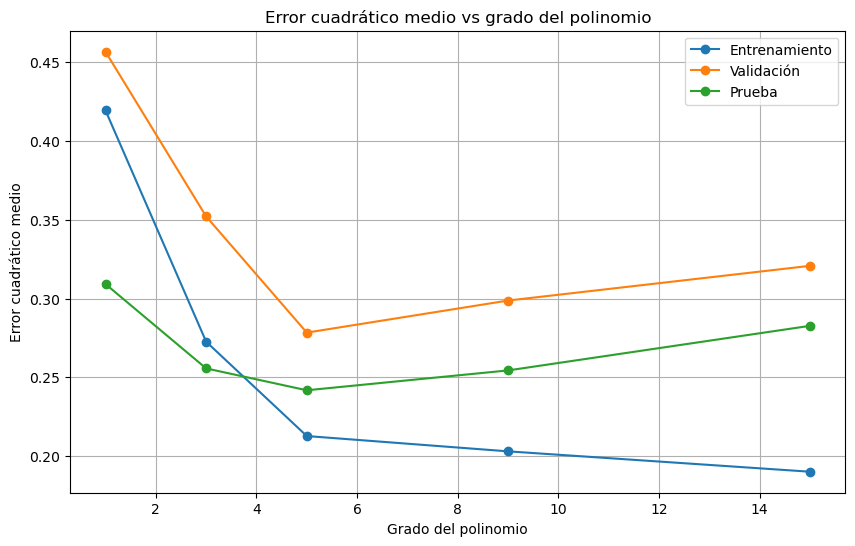

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(grados_polinomiales, errores_entrenamiento, marker="o", label="Entrenamiento")
plt.plot(grados_polinomiales, errores_validacion, marker="o", label="Validación")
plt.plot(grados_polinomiales, errores_prueba, marker="o", label="Prueba")

plt.title("Error cuadrático medio vs grado del polinomio")
plt.xlabel("Grado del polinomio")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
k_folds = 5
numero_datos = len(variable_independiente_x)
tamano_fold = numero_datos // k_folds

In [26]:
indices_mezclados = np.random.permutation(numero_datos)

In [27]:
errores_kfold = []

In [28]:
for grado_actual in grados_polinomiales:
    
    errores_por_fold = []
    
    for fold_actual in range(k_folds):
        
        inicio = fold_actual * tamano_fold
        fin = inicio + tamano_fold
        
        indices_prueba_fold = indices_mezclados[inicio:fin]
        indices_entrenamiento_fold = np.concatenate(
            (indices_mezclados[:inicio], indices_mezclados[fin:])
        )
        
        x_entrena = variable_independiente_x[indices_entrenamiento_fold]
        y_entrena = variable_dependiente_y_observada[indices_entrenamiento_fold]
        
        x_prueba_fold = variable_independiente_x[indices_prueba_fold]
        y_prueba_fold = variable_dependiente_y_observada[indices_prueba_fold]
        
        coeficientes = np.polyfit(x_entrena, y_entrena, grado_actual)
        modelo = np.poly1d(coeficientes)
        
        y_predicha = modelo(x_prueba_fold)
        error_fold = error_cuadratico_medio(y_prueba_fold, y_predicha)
        
        errores_por_fold.append(error_fold)
    
    error_promedio = np.mean(errores_por_fold)
    errores_kfold.append(error_promedio)
    
    print("Grado", grado_actual, "- Error promedio k-fold:", round(error_promedio, 4))


Grado 1 - Error promedio k-fold: 0.4204
Grado 3 - Error promedio k-fold: 0.302
Grado 5 - Error promedio k-fold: 0.2482
Grado 9 - Error promedio k-fold: 0.2654
Grado 15 - Error promedio k-fold: 0.3617


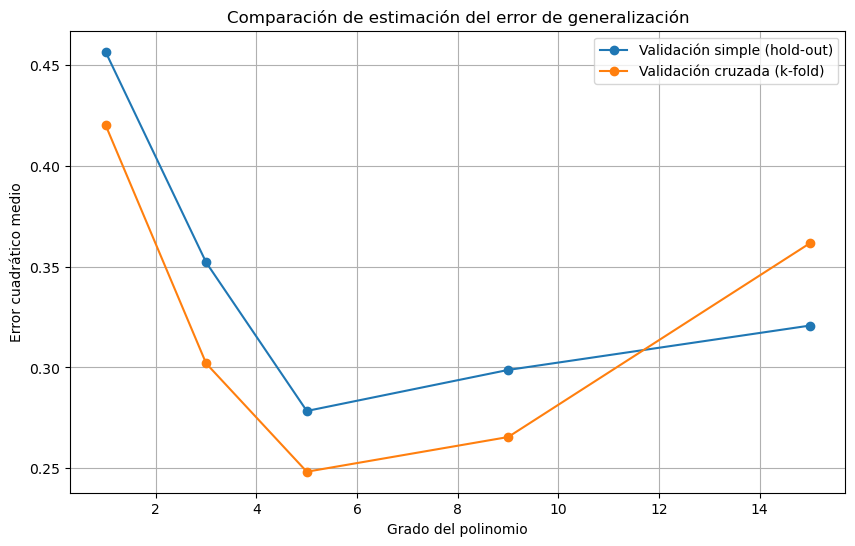

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(grados_polinomiales, errores_validacion, marker="o", label="Validación simple (hold-out)")
plt.plot(grados_polinomiales, errores_kfold, marker="o", label="Validación cruzada (k-fold)")

plt.title("Comparación de estimación del error de generalización")
plt.xlabel("Grado del polinomio")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
tamanos_muestra = [20, 40, 60, 80, 100, 150, 200]

In [31]:
def calcular_errores_por_tamano(grado_modelo):
    
    errores_entrenamiento = []
    errores_validacion = []
    
    for tamano in tamanos_muestra:
        
        x_entrena = x_entrenamiento[:tamano]
        y_entrena = y_entrenamiento[:tamano]
        
        coeficientes = np.polyfit(x_entrena, y_entrena, grado_modelo)
        modelo = np.poly1d(coeficientes)
        
        y_entrena_pred = modelo(x_entrena)
        y_valida_pred = modelo(x_validacion)
        
        error_ent = error_cuadratico_medio(y_entrena, y_entrena_pred)
        error_val = error_cuadratico_medio(y_validacion, y_valida_pred)
        
        errores_entrenamiento.append(error_ent)
        errores_validacion.append(error_val)
    
    return errores_entrenamiento, errores_validacion

In [32]:
errores_entrenamiento_g3, errores_validacion_g3 = calcular_errores_por_tamano(3)

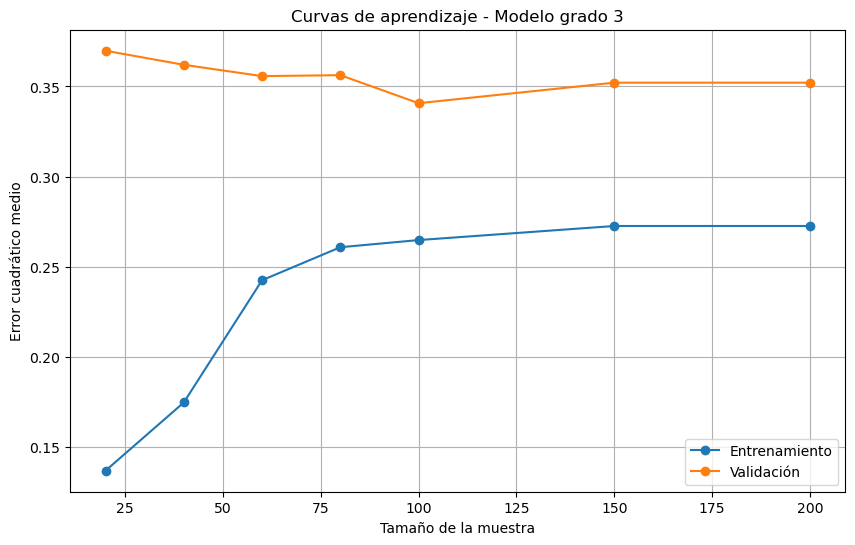

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(tamanos_muestra, errores_entrenamiento_g3, marker="o", label="Entrenamiento")
plt.plot(tamanos_muestra, errores_validacion_g3, marker="o", label="Validación")

plt.title("Curvas de aprendizaje - Modelo grado 3")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
errores_entrenamiento_g9, errores_validacion_g9 = calcular_errores_por_tamano(9)

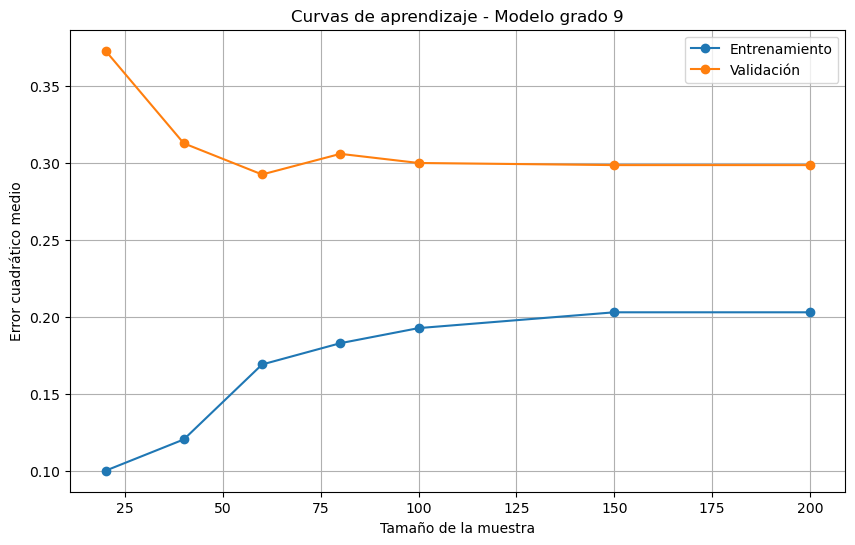

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(tamanos_muestra, errores_entrenamiento_g9, marker="o", label="Entrenamiento")
plt.plot(tamanos_muestra, errores_validacion_g9, marker="o", label="Validación")

plt.title("Curvas de aprendizaje - Modelo grado 9")
plt.xlabel("Tamaño de la muestra")
plt.ylabel("Error cuadrático medio")
plt.legend()
plt.grid(True)
plt.show()